# HW02 ICA :: Part A (Environment + OpenCV in Jupyter)

COSC 6373

Adam Nelson-Archer, 2140122

1. Create a Python virtual environment using Anaconda and name it “myenv”
2. Download and install VSCode
3. Download and install Ollama
4. Download and install OpenCV in your Python Virtual Environment
5. Make sure you use the “myenv” virtual environment from VSCode
6. Create a Python program that loads an image with OpenCV and plots it within
a Jupyter Notebook (resolve any problems that may come up with correct color
display)

## Step 6 :: OpenCV image load

OpenCV loads images in BGR channel order, Matplotlib expects RGB.

In [ ]:
from pathlib import Path

# Save artifacts next to wherever the notebook is running from.
base_dir = Path.cwd()
out_dir = base_dir / "artifacts"
out_dir.mkdir(parents=True, exist_ok=True)

print("Working directory:", base_dir)
print("Artifacts directory:", out_dir)

# Create a simple RGB demo image (gradient + colored bars)
h, w = 240, 360
img_rgb = np.zeros((h, w, 3), dtype=np.uint8)

x = np.linspace(0, 255, w, dtype=np.uint8)
img_rgb[:, :, 0] = x  # R
img_rgb[:, :, 1] = np.flipud(np.tile(np.linspace(0, 255, h, dtype=np.uint8)[:, None], (1, w)))  # G
img_rgb[:, :, 2] = 80  # B constant

# Color bars (pure colors in RGB)
bar_w = w // 6
img_rgb[:, 0*bar_w:1*bar_w] = (255, 0, 0)      # red
img_rgb[:, 1*bar_w:2*bar_w] = (0, 255, 0)      # green
img_rgb[:, 2*bar_w:3*bar_w] = (0, 0, 255)      # blue
img_rgb[:, 3*bar_w:4*bar_w] = (255, 255, 0)    # yellow
img_rgb[:, 4*bar_w:5*bar_w] = (255, 0, 255)    # magenta
img_rgb[:, 5*bar_w:6*bar_w] = (0, 255, 255)    # cyan

# Write image with OpenCV (expects BGR when writing)
img_bgr_to_write = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)
img_path = out_dir / "opencv_demo.png"
cv2.imwrite(str(img_path), img_bgr_to_write)

print("Wrote demo image to:", img_path)

Working directory: c:\Users\PC\Desktop\projects_and_code\School\COSC6373\Homework 2\Part A
Artifacts directory: c:\Users\PC\Desktop\projects_and_code\School\COSC6373\Homework 2\Part A\artifacts
Wrote demo image to: c:\Users\PC\Desktop\projects_and_code\School\COSC6373\Homework 2\Part A\artifacts\opencv_demo.png


Loaded shape (H,W,C): (240, 360, 3)
dtype: uint8


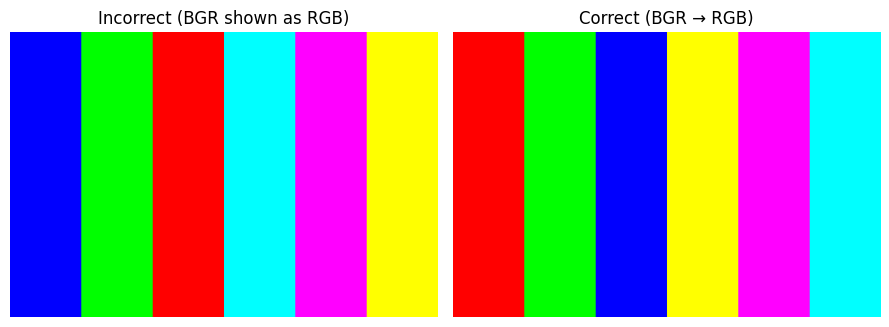

In [ ]:
# Load the image from disk with OpenCV
img_bgr = cv2.imread(str(img_path), cv2.IMREAD_COLOR)
assert img_bgr is not None, f"cv2.imread failed. Check the path: {img_path}"

print("Loaded shape (H,W,C):", img_bgr.shape)
print("dtype:", img_bgr.dtype)

# Incorrect display
plt.figure(figsize=(9, 3.5))
plt.subplot(1, 2, 1)
plt.title("Incorrect (BGR shown as RGB)")
plt.imshow(img_bgr)
plt.axis("off")

# Correct display: convert BGR -> RGB
img_rgb_fixed = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
plt.subplot(1, 2, 2)
plt.title("Correct (BGR → RGB)")
plt.imshow(img_rgb_fixed)
plt.axis("off")

plt.tight_layout()
plt.show()

## Acknowledgement

- Used a coding agent (GPT‑5.2) to draft the code cells after a the structure was established.
- Local runtime: Anaconda `myenv` + Jupyter + OpenCV.